# Customer Churn & Lifetime Value (CLTV) Prediction

This notebook implements probabilistic models for **Customer Churn Prediction** and **Customer Lifetime Value (CLTV) Estimation** using the pre-processed RFM (Recency, Frequency, Monetary, Tenure) dataset.

## Methodology
| Phase | Model / Technique | Purpose |
|-------|-------------------|--------|
| 1 | Data Preparation | Load, validate, and filter edge cases |
| 2 | BG/NBD Model | Predict future transactions & churn probability |
| 3 | Gamma-Gamma Model | Estimate average monetary value & CLTV |
| 4 | K-Means Clustering | Create actionable customer segments |
| 5 | Synthesis & Output | Consolidate results, export, and visualize |

---
## Phase 1: Environment & Data Preparation

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
    plot_period_transactions,
)
from lifetimes.utils import calibration_and_holdout_data

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


### 1.2 Load Data

In [2]:
df = pd.read_csv('rfm_customer_data.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumn dtypes:\n{df.dtypes}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (4285, 5)

Column dtypes:
Customer ID      int64
Recency          int64
Frequency        int64
Monetary       float64
Tenure           int64
dtype: object

First 5 rows:


,Customer ID,Recency,Frequency,Monetary,Tenure
0,12346,165,11,372.86,361
1,12347,3,2,1297.97,40
2,12348,74,1,221.16,74
3,12349,43,2,1996.34,225
4,12351,11,1,295.68,11


### 1.3 Data Type Validation
Ensure `Customer ID` is treated as a string identifier (not a numerical feature) and RFM columns are numeric.

In [3]:
# Ensure Customer ID is treated as a string identifier
df['Customer ID'] = df['Customer ID'].astype(str)

# Verify RFM columns are numeric
rfm_cols = ['Recency', 'Frequency', 'Monetary', 'Tenure']
for col in rfm_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Data types after validation:')
print(df.dtypes)
print(f'\nNull values:\n{df.isnull().sum()}')

Data types after validation:
Customer ID        str
Recency          int64
Frequency        int64
Monetary       float64
Tenure           int64
dtype: object

Null values:
Customer ID    0
Recency        0
Frequency      0
Monetary       0
Tenure         0
dtype: int64


### 1.4 Filter Edge Cases
The `lifetimes` library requires:
- **Monetary > 0**: Gamma-Gamma model cannot handle zero/negative monetary values.
- **Frequency > 0**: BG/NBD model needs at least 1 repeat purchase for meaningful probability estimates.
- **Tenure >= Recency**: A customer's tenure must be >= their recency (time since last purchase).

In [4]:
original_count = len(df)

# Drop rows with NaN values from coercion
df = df.dropna(subset=rfm_cols)

# Filter: Monetary must be strictly positive
df = df[df['Monetary'] > 0]

# Filter: Frequency must be > 0 (at least 1 repeat purchase)
df = df[df['Frequency'] > 0]

# Filter: Tenure must be >= Recency (logical consistency)
df = df[df['Tenure'] >= df['Recency']]

filtered_count = len(df)
print(f'Customers removed: {original_count - filtered_count} ({(original_count - filtered_count)/original_count*100:.1f}%)')
print(f'Remaining customers: {filtered_count}')
print(f'\nSummary statistics after filtering:')
df[rfm_cols].describe()

Customers removed: 0 (0.0%)
Remaining customers: 4285

Summary statistics after filtering:


,Recency,Frequency,Monetary,Tenure
count,4285.000000,4285.000000,4285.000000,4285.000000
mean,90.547025,4.429172,1429.482203,225.247375
std,96.358007,7.940396,3618.804633,118.988893
min,1.000000,1.000000,2.950000,1.000000
25%,18.000000,1.000000,264.200000,117.000000
50%,52.000000,2.000000,610.490000,253.000000
75%,136.000000,5.000000,1494.030000,330.000000
max,374.000000,183.000000,121820.490000,374.000000


---
## Phase 2: Churn & Future Transaction Modeling (BG/NBD Model)

The **Beta Geometric / Negative Binomial Distribution (BG/NBD)** model estimates:
1. The **probability that a customer is still alive** (active).
2. The **expected number of future transactions** in a given time period.

### 2.1 Fit BG/NBD Model

In [5]:
bgf = BetaGeoFitter()

try:
    # First attempt: fit without penalizer
    bgf.fit(
        frequency=df['Frequency'],
        recency=df['Recency'],
        T=df['Tenure']
    )
    print('BG/NBD model fitted successfully (no penalizer needed).')
except Exception as e:
    print(f'Initial fit failed: {e}')
    print('Retrying with penalizer_coef=0.001...')
    bgf = BetaGeoFitter(penalizer_coef=0.001)
    bgf.fit(
        frequency=df['Frequency'],
        recency=df['Recency'],
        T=df['Tenure']
    )
    print('BG/NBD model fitted successfully (with penalizer).')

print(f'\nModel Parameters:')
print(bgf.summary)

BG/NBD model fitted successfully (no penalizer needed).

Model Parameters:
            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.275754  0.004957         0.266038         0.285470
alpha   0.440618  0.017002         0.407294         0.473942
a       8.570307  1.144815         6.326470        10.814144
b      48.190594  7.068539        34.336258        62.044931


### 2.2 Predict Future Purchases
Predict the expected number of transactions over the next **30, 90, and 180 days**.

In [6]:
# Predict expected purchases for different time horizons
for period in [30, 90, 180]:
    col_name = f'Predicted_Purchases_{period}d'
    df[col_name] = bgf.predict(
        t=period,
        frequency=df['Frequency'],
        recency=df['Recency'],
        T=df['Tenure']
    )

print('Predicted purchases distribution (180-day horizon):')
print(df['Predicted_Purchases_180d'].describe())
print(f'\nTop 10 customers by expected purchases (next 180 days):')
df.nlargest(10, 'Predicted_Purchases_180d')[['Customer ID', 'Frequency', 'Recency', 'Tenure', 'Predicted_Purchases_180d']]

Predicted purchases distribution (180-day horizon):
count    4285.000000
mean        0.860029
std         1.187810
min         0.000000
25%         0.000250
50%         0.484990
75%         1.141574
max         6.226372
Name: Predicted_Purchases_180d, dtype: float64

Top 10 customers by expected purchases (next 180 days):


,Customer ID,Frequency,Recency,Tenure,Predicted_Purchases_180d
3481,17203,4,24,24,6.226372
381,12942,1,1,1,6.174588
687,13369,1,1,1,6.174588
2035,15211,1,1,1,6.174588
27,12386,1,2,2,6.014179
68,12441,1,2,2,6.014179
627,13270,1,2,2,6.014179
4109,18043,1,2,2,6.014179
4268,18269,1,2,2,6.014179
1899,15018,1,3,3,5.852335


### 2.3 Calculate Churn Risk Score

- **Probability Alive**: The conditional probability that a customer is still "active".
- **Churn Risk Score** = `1.0 - Probability_Alive`
- **Churn Flag**: Binary classification where customers with Probability_Alive < 0.2 are marked as "Churned".

In [7]:
# Calculate probability of being alive
df['Probability_Alive'] = bgf.conditional_probability_alive(
    frequency=df['Frequency'],
    recency=df['Recency'],
    T=df['Tenure']
)

# Churn Risk Score = 1 - Probability_Alive
df['Churn_Risk_Score'] = 1.0 - df['Probability_Alive']

# Hard threshold: Churned if Probability_Alive < 0.2
df['Is_Churned'] = (df['Probability_Alive'] < 0.2).astype(int)

print(f'Churn Risk Score distribution:')
print(df['Churn_Risk_Score'].describe())
print(f'\nChurn breakdown:')
print(df['Is_Churned'].value_counts().rename({0: "Active", 1: "Churned"}))
print(f'\nChurn Rate: {df["Is_Churned"].mean()*100:.1f}%')

Churn Risk Score distribution:
count    4285.000000
mean        0.603664
std         0.388540
min         0.143410
25%         0.150990
50%         0.739442
75%         0.999902
max         1.000000
Name: Churn_Risk_Score, dtype: float64

Churn breakdown:
Is_Churned
Active     2215
Churned    2070
Name: count, dtype: int64

Churn Rate: 48.3%


### 2.4 BG/NBD Visualizations

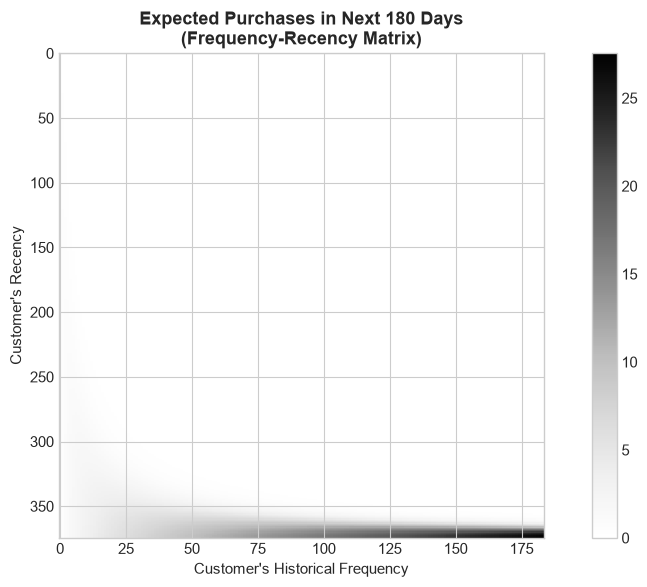

Saved: bgf_freq_recency_matrix.png


In [8]:
# Frequency-Recency Matrix: Expected number of purchases in next 180 days
plt.figure(figsize=(10, 6))
plot_frequency_recency_matrix(bgf, T=180)
plt.title('Expected Purchases in Next 180 Days\n(Frequency-Recency Matrix)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bgf_freq_recency_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bgf_freq_recency_matrix.png')

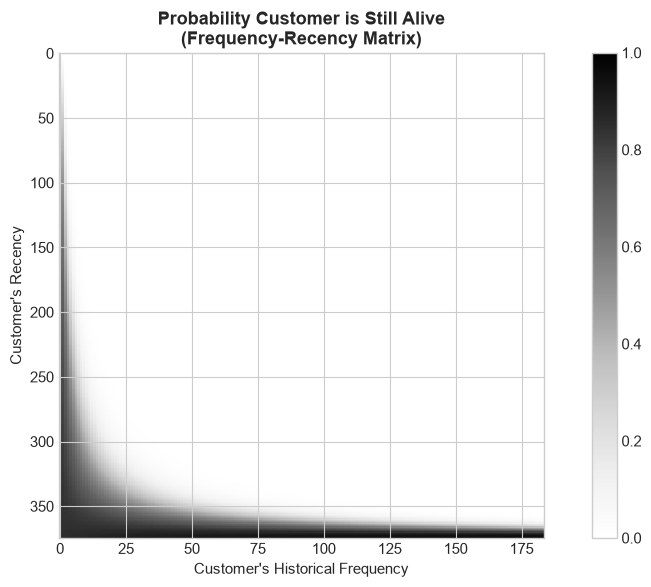

Saved: bgf_prob_alive_matrix.png


In [9]:
# Probability Alive Matrix
plt.figure(figsize=(10, 6))
plot_probability_alive_matrix(bgf)
plt.title('Probability Customer is Still Alive\n(Frequency-Recency Matrix)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bgf_prob_alive_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bgf_prob_alive_matrix.png')

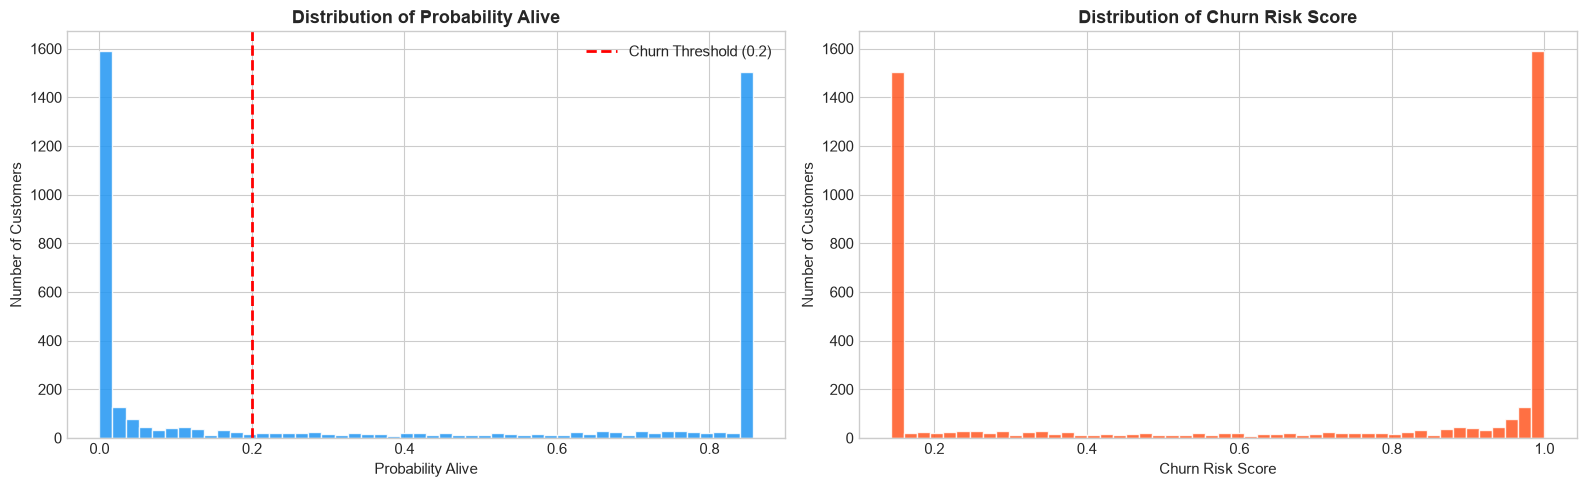

Saved: churn_risk_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of Probability Alive
axes[0].hist(df['Probability_Alive'], bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(x=0.2, color='red', linestyle='--', linewidth=2, label='Churn Threshold (0.2)')
axes[0].set_xlabel('Probability Alive')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Distribution of Probability Alive', fontsize=13, fontweight='bold')
axes[0].legend()

# Churn Risk Score distribution
axes[1].hist(df['Churn_Risk_Score'], bins=50, color='#FF5722', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Churn Risk Score')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Distribution of Churn Risk Score', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: churn_risk_distribution.png')

---
## Phase 3: Customer Value Modeling (Gamma-Gamma Model)

The **Gamma-Gamma model** estimates the **average monetary value** of a customer's future transactions, which is then combined with the BG/NBD model to produce a full **Customer Lifetime Value (CLTV)** estimate.

### 3.1 Assumption Check: Frequency vs. Monetary Independence

The Gamma-Gamma model assumes **no correlation** between purchase frequency and average monetary value. We validate this before proceeding.

Pearson Correlation (Frequency vs. Monetary): 0.8408
   The Gamma-Gamma model assumption may be violated.
   CLTV estimates should be interpreted with caution.


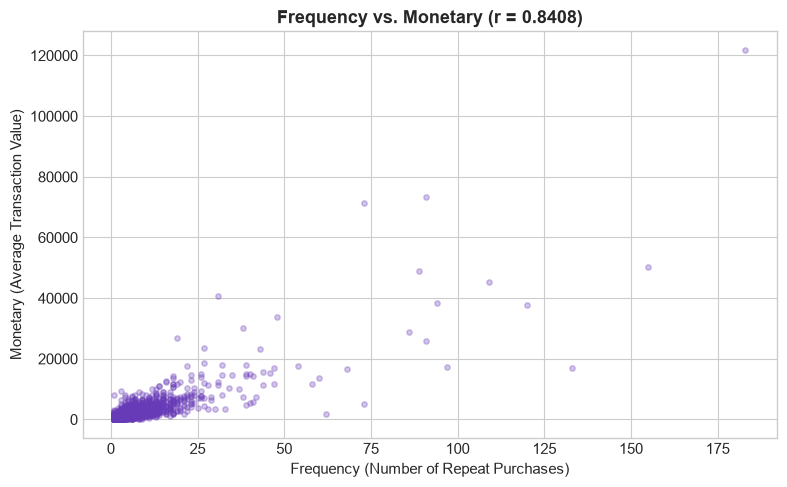

In [11]:
# Pearson correlation between Frequency and Monetary
corr = df['Frequency'].corr(df['Monetary'])
print(f'Pearson Correlation (Frequency vs. Monetary): {corr:.4f}')

if abs(corr) > 0.3:
    print(f'WARNING: Moderate/strong correlation detected ({corr:.4f}).')
    print('   The Gamma-Gamma model assumption may be violated.')
    print('   CLTV estimates should be interpreted with caution.')
else:
    print(f'Correlation is weak ({corr:.4f}). Gamma-Gamma assumption holds.')

# Visual check
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Frequency'], df['Monetary'], alpha=0.3, s=15, color='#673AB7')
ax.set_xlabel('Frequency (Number of Repeat Purchases)')
ax.set_ylabel('Monetary (Average Transaction Value)')
ax.set_title(f'Frequency vs. Monetary (r = {corr:.4f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Fit Gamma-Gamma Model

In [12]:
ggf = GammaGammaFitter()

try:
    ggf.fit(
        frequency=df['Frequency'],
        monetary_value=df['Monetary']
    )
    print('Gamma-Gamma model fitted successfully (no penalizer needed).')
except Exception as e:
    print(f'Initial fit failed: {e}')
    print('Retrying with penalizer_coef=0.001...')
    ggf = GammaGammaFitter(penalizer_coef=0.001)
    ggf.fit(
        frequency=df['Frequency'],
        monetary_value=df['Monetary']
    )
    print('Gamma-Gamma model fitted successfully (with penalizer).')

print(f'\nModel Parameters:')
print(ggf.summary)

Gamma-Gamma model fitted successfully (no penalizer needed).

Model Parameters:
          coef    se(coef)  lower 95% bound  upper 95% bound
p     0.971206    0.039190         0.894393         1.048018
q     1.736262    0.057379         1.623799         1.848725
v  1362.774250  118.375168      1130.758921      1594.789580


### 3.3 Calculate Customer Lifetime Value (CLTV)

Combine BG/NBD and Gamma-Gamma models to estimate the total expected monetary value from each customer over a **6-month (180-day) horizon** with a monthly discount rate of 1%.

In [13]:
# Calculate CLTV over 6-month horizon
# time=6 means 6 months, discount_rate=0.01 is monthly
# freq='D' since our RFM data is in daily units
df['Predicted_CLTV'] = ggf.customer_lifetime_value(
    transaction_prediction_model=bgf,
    frequency=df['Frequency'],
    recency=df['Recency'],
    T=df['Tenure'],
    monetary_value=df['Monetary'],
    time=6,           # 6 months
    discount_rate=0.01,  # monthly discount rate
    freq='D'          # RFM data in daily granularity
)

print('CLTV Distribution:')
print(df['Predicted_CLTV'].describe())
print(f'\nTotal Predicted Revenue (6-month): ${df["Predicted_CLTV"].sum():,.2f}')
print(f'Average CLTV per Customer: ${df["Predicted_CLTV"].mean():,.2f}')
print(f'Median CLTV per Customer: ${df["Predicted_CLTV"].median():,.2f}')

CLTV Distribution:
count     4285.000000
mean       802.130049
std       1227.224659
min          0.000000
25%          0.299096
50%        411.837083
75%       1058.223738
max      26267.854746
Name: Predicted_CLTV, dtype: float64

Total Predicted Revenue (6-month): $3,437,127.26
Average CLTV per Customer: $802.13
Median CLTV per Customer: $411.84


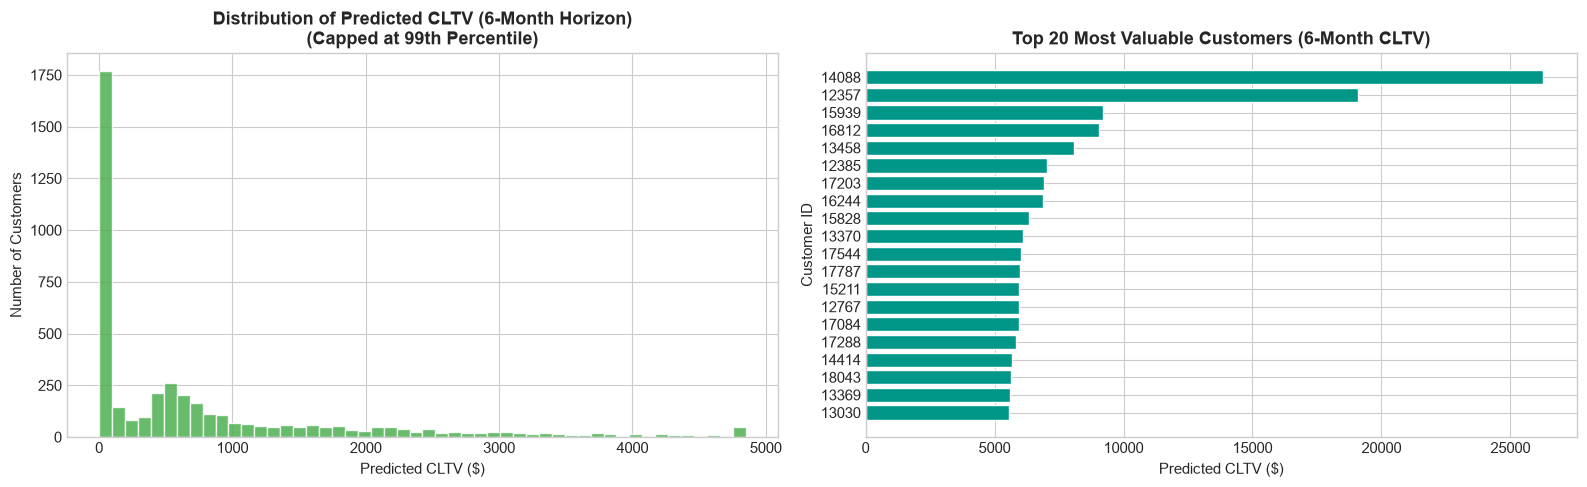

Saved: cltv_distribution.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# CLTV Distribution (capped at 99th percentile for visibility)
cap = df['Predicted_CLTV'].quantile(0.99)
axes[0].hist(df['Predicted_CLTV'].clip(upper=cap), bins=50, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Predicted CLTV ($)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Distribution of Predicted CLTV (6-Month Horizon)\n(Capped at 99th Percentile)', fontsize=13, fontweight='bold')

# Top 20 customers by CLTV
top20 = df.nlargest(20, 'Predicted_CLTV')
axes[1].barh(top20['Customer ID'], top20['Predicted_CLTV'], color='#009688', edgecolor='white')
axes[1].set_xlabel('Predicted CLTV ($)')
axes[1].set_ylabel('Customer ID')
axes[1].set_title('Top 20 Most Valuable Customers (6-Month CLTV)', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('cltv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cltv_distribution.png')

---
## Phase 4: Customer Segmentation (K-Means Clustering)

Combine historical RFM metrics with predicted CLTV and Churn Risk to create actionable customer segments.

### 4.1 Feature Selection & Scaling

In [15]:
# Features for clustering
cluster_features = ['Recency', 'Frequency', 'Monetary', 'Predicted_CLTV', 'Churn_Risk_Score']

# Prepare the feature matrix
X = df[cluster_features].copy()

# Standardize features (K-Means is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)
print('\nScaled feature statistics:')
pd.DataFrame(X_scaled, columns=cluster_features).describe().round(3)

Feature matrix shape: (4285, 5)

Scaled feature statistics:


,Recency,Frequency,Monetary,Predicted_CLTV,Churn_Risk_Score
count,4285.000,4285.000,4285.000,4285.000,4285.000
mean,0.000,0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000
min,-0.929,-0.432,-0.394,-0.654,-1.185
25%,-0.753,-0.432,-0.322,-0.653,-1.165
50%,-0.400,-0.306,-0.226,-0.318,0.349
75%,0.472,0.072,0.018,0.209,1.020
max,2.942,22.492,33.272,20.753,1.020


### 4.2 Determine Optimal Number of Clusters
Using the **Elbow Method** (WCSS) and **Silhouette Score** to find the optimal `k`.

k= 2 | WCSS:     13,536.6 | Silhouette: 0.5087


k= 3 | WCSS:      9,504.0 | Silhouette: 0.5196


k= 4 | WCSS:      6,548.2 | Silhouette: 0.5705


k= 5 | WCSS:      5,129.6 | Silhouette: 0.5840


k= 6 | WCSS:      4,399.0 | Silhouette: 0.5396


k= 7 | WCSS:      3,839.6 | Silhouette: 0.5373


k= 8 | WCSS:      3,336.7 | Silhouette: 0.4684


k= 9 | WCSS:      2,951.8 | Silhouette: 0.4552


k=10 | WCSS:      2,520.9 | Silhouette: 0.4542


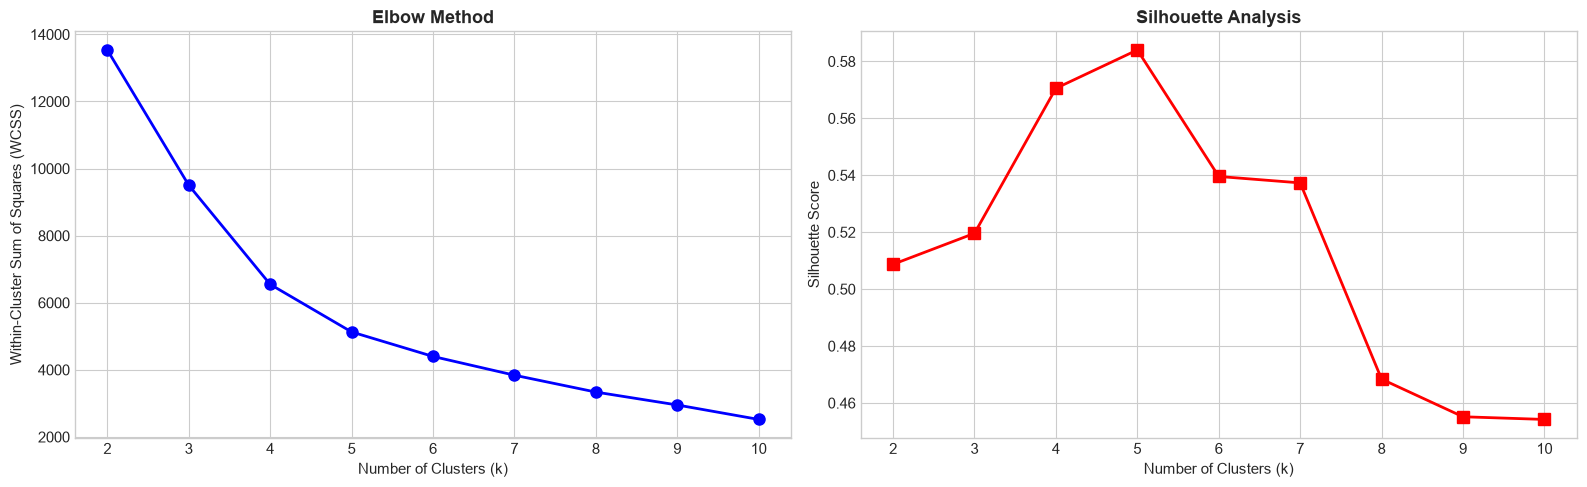

Saved: optimal_clusters.png


In [16]:
K_range = range(2, 11)
wcss = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)
    print(f'k={k:2d} | WCSS: {kmeans.inertia_:12,.1f} | Silhouette: {sil_score:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Method
axes[0].plot(list(K_range), wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(K_range))

# Silhouette Score
axes[1].plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis', fontsize=13, fontweight='bold')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('optimal_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: optimal_clusters.png')

### 4.3 Fit K-Means with Optimal k
Based on the elbow method and silhouette analysis, we use **k=4** to create interpretable segments:
- Champions, Loyal, At-Risk, and Hibernating/Lost.

In [17]:
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10, max_iter=300)
df['Cluster_ID'] = kmeans_final.fit_predict(X_scaled)

print(f'K-Means fitted with k={OPTIMAL_K}')
print(f'\nCluster distribution:')
print(df['Cluster_ID'].value_counts().sort_index())
print(f'\nCluster centroids (scaled):')
pd.DataFrame(kmeans_final.cluster_centers_, columns=cluster_features).round(3)

K-Means fitted with k=4

Cluster distribution:
Cluster_ID
0    2259
1     893
2    1117
3      16
Name: count, dtype: int64

Cluster centroids (scaled):


,Recency,Frequency,Monetary,Predicted_CLTV,Churn_Risk_Score
0,-0.552,0.255,0.167,-0.571,0.903
1,-0.417,-0.392,-0.270,1.516,-1.052
2,1.462,-0.365,-0.289,-0.048,-0.999
3,-0.893,11.297,11.651,-0.654,1.020


### 4.4 Interpret and Name Segments
Assign human-readable labels based on each cluster's RFM/CLTV/Churn profile.

In [18]:
# Compute cluster profiles
cluster_profile = df.groupby('Cluster_ID')[cluster_features].mean()
print('Cluster Profiles (Mean Values):')
print(cluster_profile.round(2).to_string())

# Auto-label strategy:
# Rank clusters by Predicted_CLTV (descending) to assign names
cltv_ranking = cluster_profile['Predicted_CLTV'].sort_values(ascending=False).index.tolist()

segment_names = {
    cltv_ranking[0]: 'Champions',        # Highest CLTV
    cltv_ranking[1]: 'Loyal Customers',   # Second highest CLTV
    cltv_ranking[2]: 'At-Risk',           # Third
    cltv_ranking[3]: 'Hibernating/Lost',  # Lowest CLTV
}

df['Customer_Segment'] = df['Cluster_ID'].map(segment_names)

print(f'\nSegment Counts:')
print(df['Customer_Segment'].value_counts())
print(f'\nSegment Profiles (Mean Values):')
df.groupby('Customer_Segment')[cluster_features].mean().round(2)

Cluster Profiles (Mean Values):
            Recency  Frequency  Monetary  Predicted_CLTV  Churn_Risk_Score
Cluster_ID                                                                
0             37.40       6.46   2035.36          101.23              0.95
1             50.32       1.32    450.72         2662.84              0.19
2            231.43       1.53    382.76          743.54              0.22
3              4.50      94.12  43588.71            0.00              1.00

Segment Counts:
Customer_Segment
At-Risk             2259
Loyal Customers     1117
Champions            893
Hibernating/Lost      16
Name: count, dtype: int64

Segment Profiles (Mean Values):


,Recency,Frequency,Monetary,Predicted_CLTV,Churn_Risk_Score
Customer_Segment,,,,,
At-Risk,37.40,6.46,2035.36,101.23,0.95
Champions,50.32,1.32,450.72,2662.84,0.19
Hibernating/Lost,4.50,94.12,43588.71,0.00,1.00
Loyal Customers,231.43,1.53,382.76,743.54,0.22


---
## Phase 5: Synthesis & Output

### 5.1 Master DataFrame

In [19]:
# Select and order columns for the final output
output_cols = [
    'Customer ID',
    'Recency', 'Frequency', 'Monetary', 'Tenure',
    'Predicted_Purchases_30d', 'Predicted_Purchases_90d', 'Predicted_Purchases_180d',
    'Probability_Alive', 'Churn_Risk_Score', 'Is_Churned',
    'Predicted_CLTV',
    'Cluster_ID', 'Customer_Segment'
]

df_final = df[output_cols].copy()
print(f'Final dataset shape: {df_final.shape}')
print(f'\nColumns: {list(df_final.columns)}')
df_final.head(10)

Final dataset shape: (4285, 14)

Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Tenure', 'Predicted_Purchases_30d', 'Predicted_Purchases_90d', 'Predicted_Purchases_180d', 'Probability_Alive', 'Churn_Risk_Score', 'Is_Churned', 'Predicted_CLTV', 'Cluster_ID', 'Customer_Segment']


,Customer ID,Recency,Frequency,Monetary,Tenure,Predicted_Purchases_30d,Predicted_Purchases_90d,Predicted_Purchases_180d,Probability_Alive,Churn_Risk_Score,Is_Churned,Predicted_CLTV,Cluster_ID,Customer_Segment
0,12346,165,11,372.86,361,0.000888,0.002363,0.004008,0.001010,0.998990,1,1.805462,0,At-Risk
1,12347,3,2,1297.97,40,0.029540,0.067639,0.098956,0.020624,0.979376,1,138.187775,0,At-Risk
2,12348,74,1,221.16,74,0.408785,1.089098,1.867261,0.849010,0.150990,0,1630.214415,1,Champions
3,12349,43,2,1996.34,225,0.034986,0.098833,0.181651,0.119203,0.880797,1,341.275813,0,At-Risk
4,12351,11,1,295.68,11,1.977450,3.708473,4.745091,0.849010,0.150990,0,4373.834427,1,Champions
5,12352,11,2,338.55,28,0.802414,1.696123,2.320804,0.419455,0.580545,0,1673.296741,1,Champions
6,12353,44,1,317.76,44,0.656720,1.639765,2.624860,0.849010,0.150990,0,2435.392965,1,Champions
7,12355,203,1,469.66,203,0.155847,0.445975,0.834496,0.849010,0.150990,0,841.255879,2,Loyal Customers
8,12356,16,3,2199.42,60,0.107124,0.251493,0.374457,0.076055,0.923945,1,771.379193,0,At-Risk
9,12357,24,1,8206.45,24,1.102902,2.476006,3.600919,0.849010,0.150990,0,19073.056564,1,Champions


### 5.2 Sanity Check: Segment Statistics

In [20]:
# Descriptive statistics grouped by segment
segment_stats = df_final.groupby('Customer_Segment').agg({
    'Customer ID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Predicted_CLTV': ['mean', 'median', 'sum'],
    'Churn_Risk_Score': 'mean',
    'Probability_Alive': 'mean',
    'Predicted_Purchases_180d': 'mean',
}).round(2)

segment_stats.columns = [
    'Count', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary',
    'Mean_CLTV', 'Median_CLTV', 'Total_CLTV',
    'Avg_Churn_Risk', 'Avg_Prob_Alive', 'Avg_Predicted_Purchases_180d'
]

print('Segment Summary Statistics:')
print('=' * 120)
segment_stats

Segment Summary Statistics:


,Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Mean_CLTV,Median_CLTV,Total_CLTV,Avg_Churn_Risk,Avg_Prob_Alive,Avg_Predicted_Purchases_180d
Customer_Segment,,,,,,,,,,
At-Risk,2259,37.40,6.46,2035.36,101.23,0.95,228681.47,0.95,0.05,0.10
Champions,893,50.32,1.32,450.72,2662.84,2295.52,2377913.27,0.19,0.81,2.81
Hibernating/Lost,16,4.50,94.12,43588.71,0.00,0.00,0.00,1.00,0.00,0.00
Loyal Customers,1117,231.43,1.53,382.76,743.54,666.28,830532.51,0.22,0.78,0.85


### 5.3 Export Results

In [21]:
output_file = 'customer_cltv_predictions_and_segments.csv'
df_final.to_csv(output_file, index=False)
print(f'Results exported to: {output_file}')
print(f'   Rows: {len(df_final):,}')
print(f'   Columns: {len(df_final.columns)}')
print(f'   File size: {os.path.getsize(output_file) / 1024:.1f} KB')

Results exported to: customer_cltv_predictions_and_segments.csv
   Rows: 4,285
   Columns: 14
   File size: 656.9 KB


### 5.4 Final Visualizations

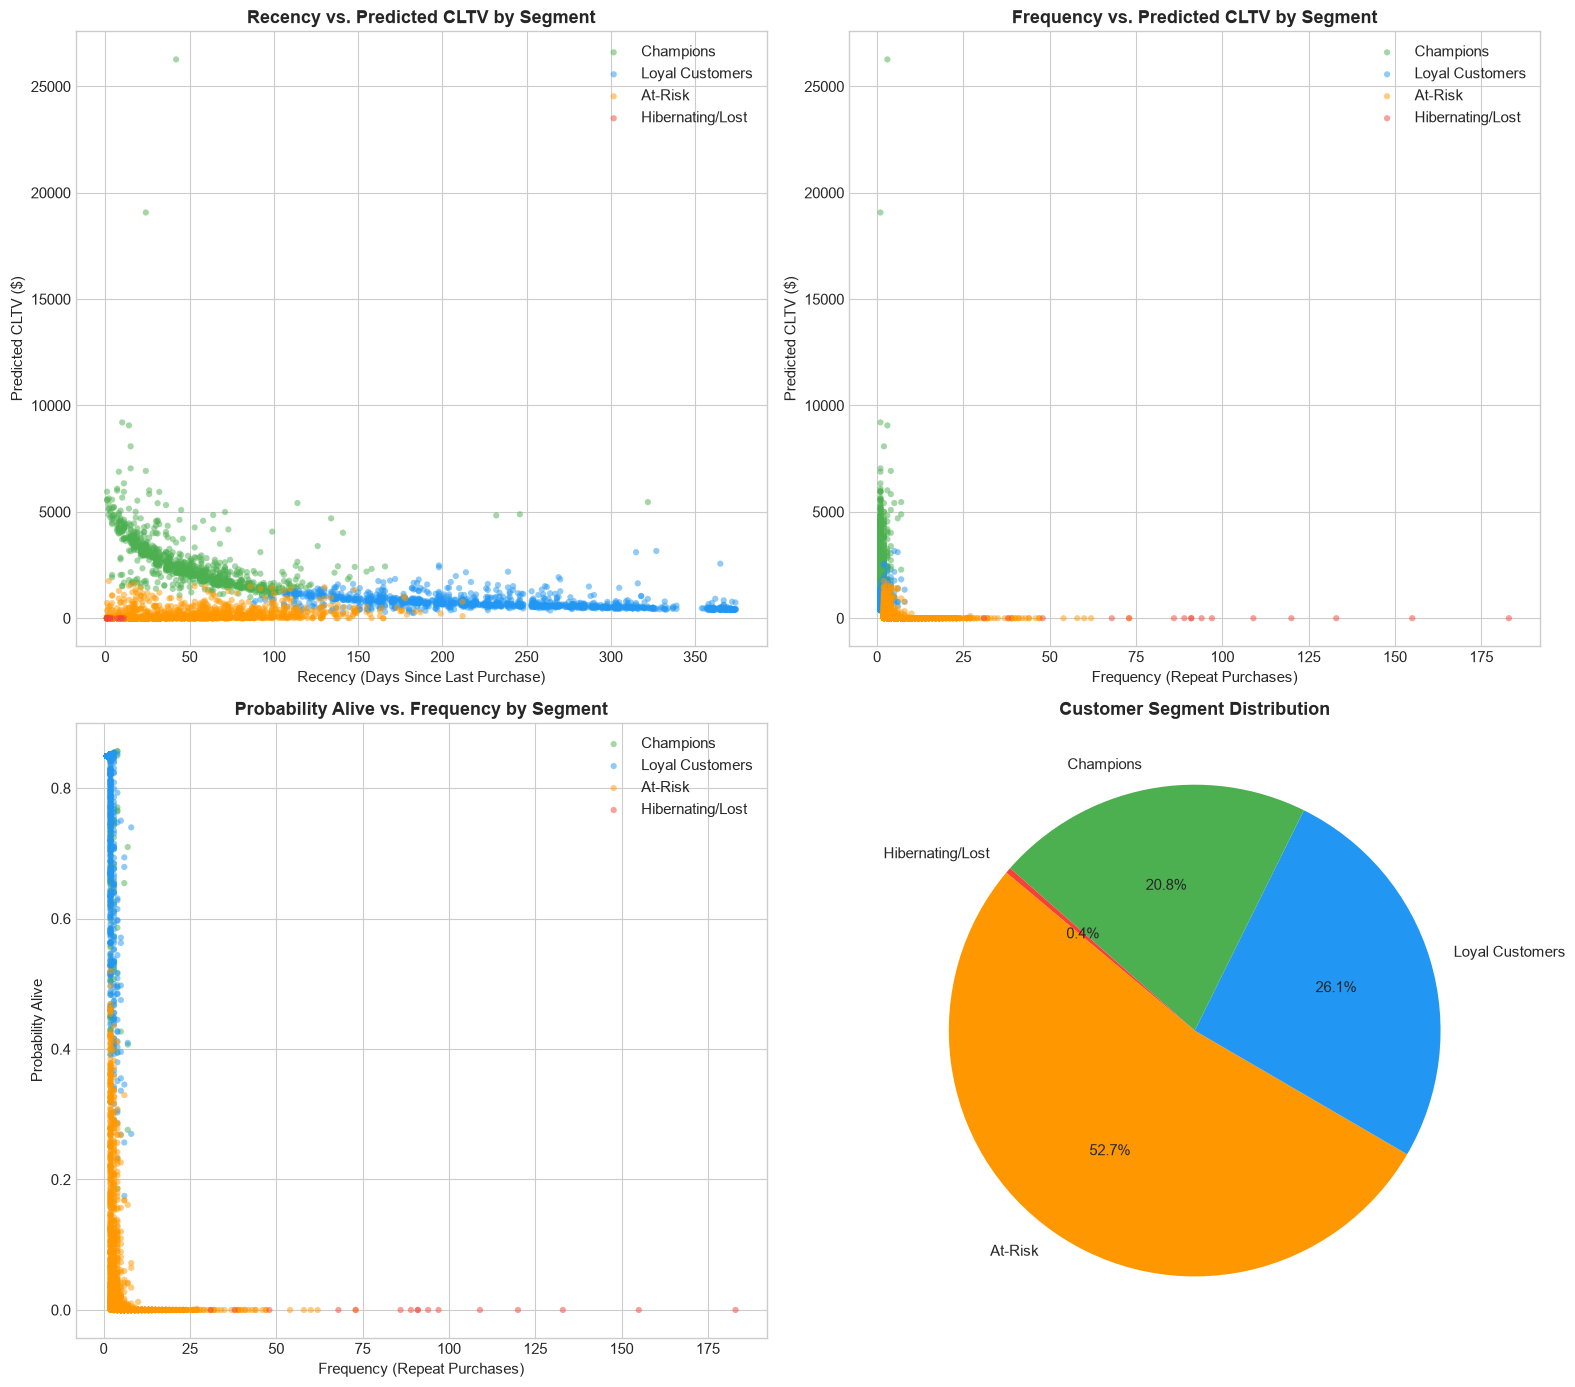

Saved: customer_segments_analysis.png


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

segment_colors = {
    'Champions': '#4CAF50',
    'Loyal Customers': '#2196F3',
    'At-Risk': '#FF9800',
    'Hibernating/Lost': '#F44336'
}

# 1. Recency vs Predicted CLTV
for segment, color in segment_colors.items():
    mask = df_final['Customer_Segment'] == segment
    axes[0, 0].scatter(
        df_final.loc[mask, 'Recency'],
        df_final.loc[mask, 'Predicted_CLTV'],
        c=color, label=segment, alpha=0.5, s=20, edgecolors='none'
    )
axes[0, 0].set_xlabel('Recency (Days Since Last Purchase)')
axes[0, 0].set_ylabel('Predicted CLTV ($)')
axes[0, 0].set_title('Recency vs. Predicted CLTV by Segment', fontsize=13, fontweight='bold')
axes[0, 0].legend()

# 2. Frequency vs Predicted CLTV
for segment, color in segment_colors.items():
    mask = df_final['Customer_Segment'] == segment
    axes[0, 1].scatter(
        df_final.loc[mask, 'Frequency'],
        df_final.loc[mask, 'Predicted_CLTV'],
        c=color, label=segment, alpha=0.5, s=20, edgecolors='none'
    )
axes[0, 1].set_xlabel('Frequency (Repeat Purchases)')
axes[0, 1].set_ylabel('Predicted CLTV ($)')
axes[0, 1].set_title('Frequency vs. Predicted CLTV by Segment', fontsize=13, fontweight='bold')
axes[0, 1].legend()

# 3. Probability Alive vs Frequency
for segment, color in segment_colors.items():
    mask = df_final['Customer_Segment'] == segment
    axes[1, 0].scatter(
        df_final.loc[mask, 'Frequency'],
        df_final.loc[mask, 'Probability_Alive'],
        c=color, label=segment, alpha=0.5, s=20, edgecolors='none'
    )
axes[1, 0].set_xlabel('Frequency (Repeat Purchases)')
axes[1, 0].set_ylabel('Probability Alive')
axes[1, 0].set_title('Probability Alive vs. Frequency by Segment', fontsize=13, fontweight='bold')
axes[1, 0].legend()

# 4. Segment breakdown (pie chart)
seg_counts = df_final['Customer_Segment'].value_counts()
colors = [segment_colors[s] for s in seg_counts.index]
axes[1, 1].pie(
    seg_counts.values, labels=seg_counts.index, colors=colors,
    autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11}
)
axes[1, 1].set_title('Customer Segment Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('customer_segments_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: customer_segments_analysis.png')

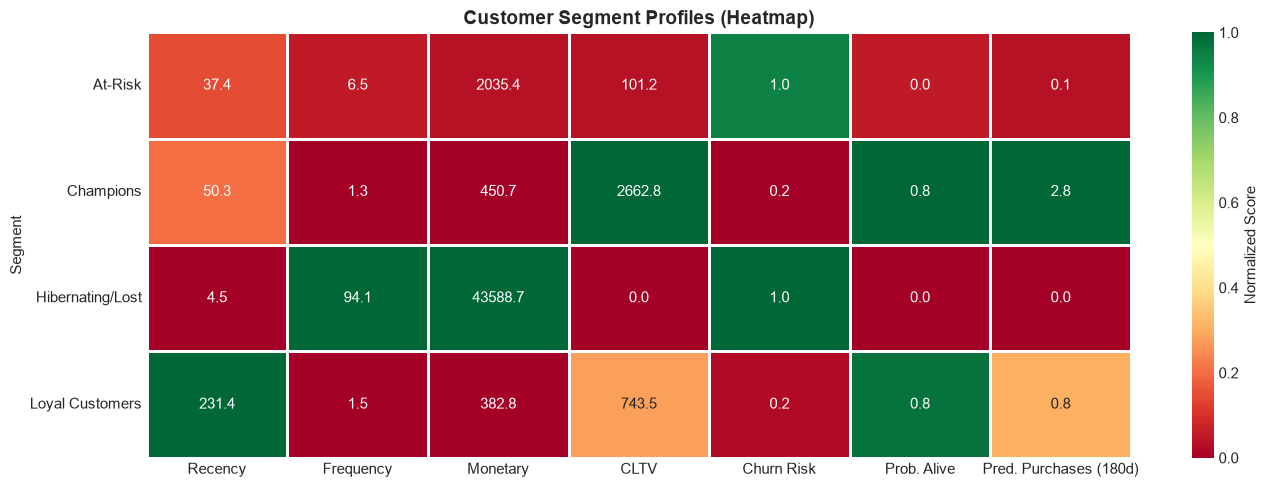

Saved: segment_heatmap.png


In [23]:
# Heatmap of segment profiles
profile_data = df_final.groupby('Customer_Segment')[[
    'Recency', 'Frequency', 'Monetary', 'Predicted_CLTV',
    'Churn_Risk_Score', 'Probability_Alive', 'Predicted_Purchases_180d'
]].mean()

# Normalize for heatmap
profile_normalized = (profile_data - profile_data.min()) / (profile_data.max() - profile_data.min())

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    profile_normalized,
    annot=profile_data.round(1).values,
    fmt='', cmap='RdYlGn', linewidths=1, linecolor='white',
    ax=ax, cbar_kws={'label': 'Normalized Score'},
    xticklabels=['Recency', 'Frequency', 'Monetary', 'CLTV',
                 'Churn Risk', 'Prob. Alive', 'Pred. Purchases (180d)']
)
ax.set_title('Customer Segment Profiles (Heatmap)', fontsize=14, fontweight='bold')
ax.set_ylabel('Segment')
plt.tight_layout()
plt.savefig('segment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: segment_heatmap.png')

---
## Summary

### Models Used
- **BG/NBD Model**: Predicted future purchase probability and churn risk
- **Gamma-Gamma Model**: Estimated average transaction value and CLTV
- **K-Means Clustering**: Segmented customers into actionable groups

### Output Files
| File | Description |
|------|-------------|
| `customer_cltv_predictions_and_segments.csv` | Final dataset with predictions and segments |
| `bgf_freq_recency_matrix.png` | BG/NBD frequency-recency matrix |
| `bgf_prob_alive_matrix.png` | BG/NBD probability alive matrix |
| `churn_risk_distribution.png` | Churn risk score distribution |
| `cltv_distribution.png` | CLTV distribution and top customers |
| `optimal_clusters.png` | Elbow method and silhouette analysis |
| `customer_segments_analysis.png` | Scatter plots and pie chart of segments |
| `segment_heatmap.png` | Heatmap of segment profiles |